# All of Softtorch

Softtorch provides easy-to-use differentiable function surrogates of non-differentiable functions and discrete logic operations in PyTorch. Softtorch offers **soft function surrogates operating on real values, Booleans, and indices** as well as wrappers to use these functions for gradient-based optimization.

This pages guides you through all of Softtorch key functionalities.


In [1]:
import torch
from plot_utils import (
    configure_plots,
    plot,
    plot_array,
    plot_softbool_operation,
    plot_softindices_1D,
    plot_value_and_grad,
    plot_value_grad_2D,
)


configure_plots()

## 1. Softening
Many functions are not particulary well suited for gradient-based optimization as their gradients are either zero or undefined at discontinuities. Therefore, a typical approach in machine learning is to use soft surrogates for these functions to enable gradient-based optimization via automatic differentiation. Softtorch provides such soft surrogates for many operations in PyTorch.

As shown below, Softtorch provides two hyper-parameters to tune soft function surrogates:

- **mode** being the type of function used for obtaining a soft approximation. 

- **softness** defining how close the surrogate function approximates the original function.


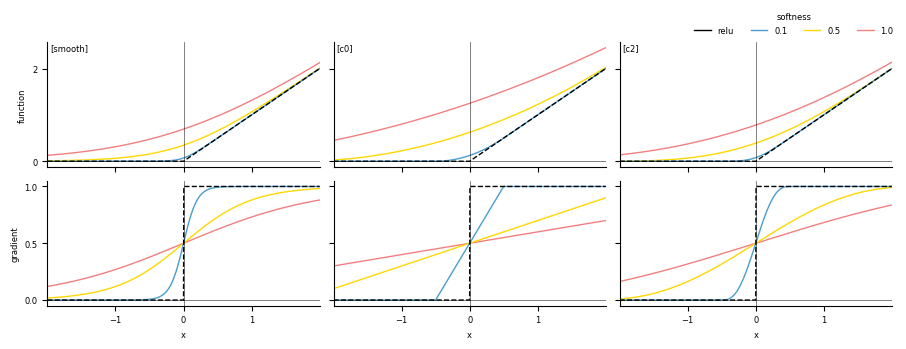

In [2]:
import softtorch as st

plot(st.relu, modes=["smooth", "c0", "c2"])

Softtorch provides function surrogates for many other function such as the **absolute function**.

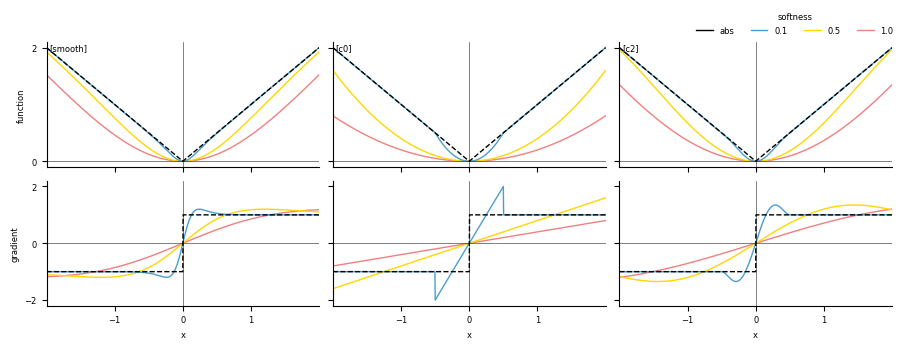

In [3]:
plot(st.abs, modes=["smooth", "c0", "c2"])

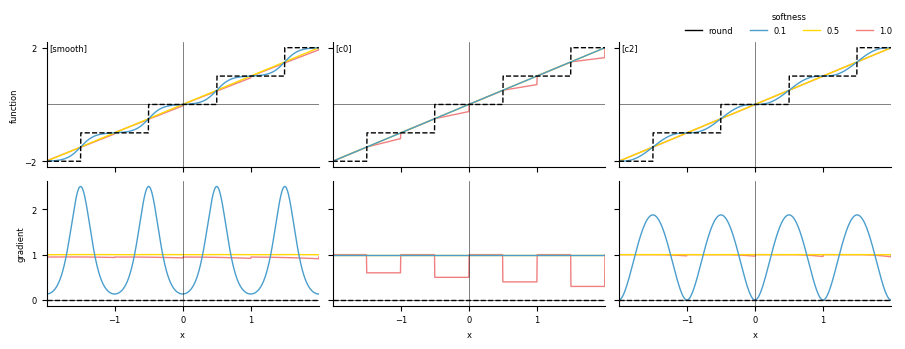

In [4]:
plot(st.round, modes=["smooth", "c0", "c2"])

## 2. Straight-through estimation
Soft function surrogates can be used to compute *soft gradients* (or more accurately: *soft vector-jacobian-producs*) without modifying the forward pass via [straight-through estimation](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.gumbel_softmax.html). Straight-through estimation uses PyTorch's [automatic differentiation system](https://docs.torch.dev/en/latest/notebooks/autodiff_cookbook.html) to replace only the function's gradient with the gradient of the surrogate function.


> **Note:** Historically, straight-through estimators refer to the special case of treating a function as the [identity operation on the backward pass](https://arxiv.org/pdf/1308.3432). We use the term more generally to describe the case of replacing a function with smooth a surrogate on the backward pass.


> **Example - ReLu activation:** The [rectified linear unit](https://en.wikipedia.org/wiki/Rectified_linear_unit) (aka `relu`)  is commonly used as activation function in neural networks. For $x<0$ the gradient of the `relu` is zero. In turn, neural networks containing `relu` activations may suffer from the ["dying ReLu problem"](https://arxiv.org/abs/1903.06733) where the gradients computed via automatic differentiation become zero when a gradient-based optimizer adjusts the inputs of ReLU functions to $x<0$.
As pointed out in ["The Resurrection of the ReLU"](https://arxiv.org/pdf/2505.22074), you can mitigate these problems by replacing its backward pass with a soft surrogate function. To do this with Softtorch, simply replace the `relu` activation in your code with `st.st(st.relu)`, or equivalently directly use our wrapped primitives via `st.relu_st` for convenience.


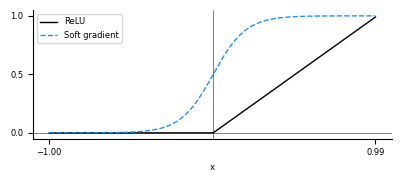

In [5]:
soft_relu = st.st(st.relu)

x = torch.arange(-1, 1, 0.01)
values = []
grads = []
for x_i in x:
    xi = x_i.clone().detach().requires_grad_(True)
    y = soft_relu(xi)
    (g,) = torch.autograd.grad(y, xi)
    values.append(y.item())
    grads.append(g.item())

plot_value_and_grad(x, values, grads, label_func="ReLU", label_grad="Soft gradient")



### The STE Trick
Under the hood `st.st()` uses the [stop-gradient](https://docs.pytorch.org/docs/stable/generated/torch.Tensor.detach.html) operation to replace the gradient of a function.

```python
def st(fn: Callable) -> Callable:
    sig = inspect.signature(fn)
    mode_default = sig.parameters.get("mode").default
    def wrapped(*args, **kwargs):
        mode = kwargs.pop("mode", mode_default)
        fw_y = fn(*args, **kwargs, mode="hard")
        bw_y = fn(*args, **kwargs, mode=mode)
        return torch.utils._pytree.tree_map(
            lambda f, b: (f - b).detach() + b, fw_y, bw_y
        )
    return wrapped
```

By adding and subtracting the backward function `bw_y` to the function call, it does not alter the function's forward pass `fw_y`. Due to `.detach()`, only the *soft* backward function `bw_y` is used in the gradient computation.



### Custom differentiation rules
The `@st.st` decorator can also be used to define custom straight-through operations. 
This can be useful when combining multiple functions provided by the softtorch library. For this, it is important to understand, that simply applying the straight-through trick to every non-smooth function does not always result in the intended behavior.
Consider for example the case of multiplying the output of two `relu` functions together. This function only provides meaningful gradients in the first quadrant, we would like to change it such that we get a meaningful signal in the whole domain, as visualized below.

Note: We normalize the plotted gradient vectors for reduced cluttering.

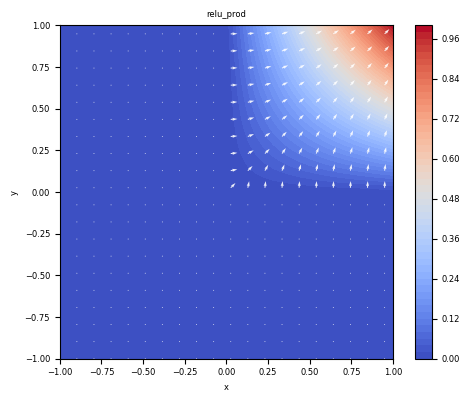

In [6]:
def relu_prod(x, y):
    # Standard ReLU product, no softening
    return torch.relu(x) * torch.relu(y)


plot_value_grad_2D(relu_prod)


A naive approach would be to replace each relu with `st.relu_st` independently. However, the resulting function will not provide informative gradients for every input.
This is due to the chain rule, in which the gradient flowing through one relu is multiplid by the (forward) output of the other relu. As the forward pass is not smoothed, the gradient will sometimes be multiplied by zero, resulting in no informative gradient.

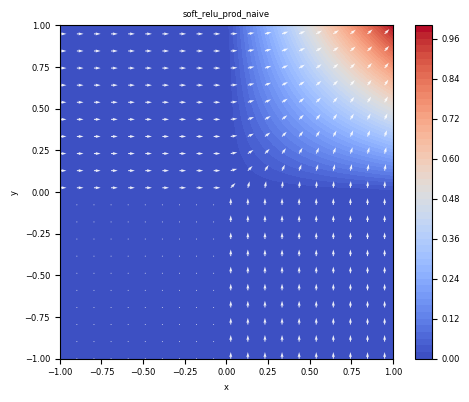

In [7]:
def soft_relu_prod_naive(x, y, mode="smooth", softness=0.1):
    # Naive straight-through implementation
    return st.relu_st(x, mode=mode, softness=softness) * st.relu_st(
        y, mode=mode, softness=softness
    )


plot_value_grad_2D(soft_relu_prod_naive)

An alternative approach for softening this function is to apply the straight through trick on the **outer level** as illustrated below.
When applied on the outer level, the forward pass computes the hard product of ReLUs as before, whereas the backward pass differentiates through the product of smooth relus.

Notice that we use st.relu instead of st.relu_st here.

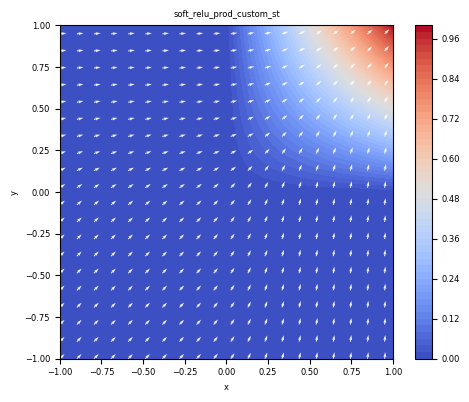

In [8]:
@st.st
def soft_relu_prod_custom_st(x, y, mode="smooth", softness=0.1):
    # Custom straight-through implementation
    return st.relu(x, mode=mode, softness=softness) * st.relu(
        y, mode=mode, softness=softness
    )


plot_value_grad_2D(soft_relu_prod_custom_st)

We observe that as expected, this version of the function now also produces informative gradients in the third quadrant.
In the simple above example, the only both `st.relu` functions take the same parameters, therefore it was easy to just apply the `st.st` decorator again.

In general, we might want to define custom behavior. This can be implemented by using the `@st.grad_replace` decorator, which allows custom control flow conditioned on a `forward` boolean variable. The function will then execute with `forward=True` on the forward pass and `forward=False` on the backward pass.

```python
def grad_replace(fn: Callable) -> Callable:
    def wrapped(*args, **kwargs):
        fw_y = fn(*args, **kwargs, forward=True)
        bw_y = fn(*args, **kwargs, forward=False)
        return torch.utils._pytree.tree_map(
            lambda f, b: (f - b).detach() + b, fw_y, bw_y
        )
    return wrapped
```

## 3. Soft bools
Softtorch provides differentiable surrogates of PyTorch's Boolean operators. A Boolean (aka Bool) is a data type that takes one of two possible values either being `false` or `true` (aka 0 or 1). Many operations in PyTorch such as `greater` or `isclose` generate arrays containing Booleans, while other operations such as `logical_and` or `any` operate on such arrays. 

> **Example - `torch.numpy.greater` is not differentiable:** As shown below, calling `backward` on a loss computed from the boolean output, raises an exception. Even if PyTorch would gradient computation, the returned gradients would be zero for all array entries.

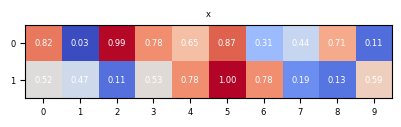

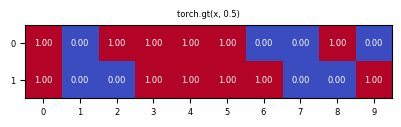

Backward raised an exception: element 0 of tensors does not require grad and does not have a grad_fn


In [9]:
x = torch.rand((2, 10), requires_grad=True)
bool_array = torch.gt(x, 0.5).float()


plot_array(x, title="x")
plot_array(bool_array, title="torch.gt(x, 0.5)")

try:
    loss = bool_array.sum()
    loss.backward()
except Exception as e:
    print(f"Backward raised an exception: {e}")


> **Example - `softtorch.greater_st` yields useful gradients:** Instead of `torch.numpy.greater`, let's use `softtorch.greater_st` (straight_through variant of `softtorch.greater`). As shown below, thanks to straight-through estimation, `softtorch.greater_st` yields exact Booleans while the gradient of the Boolean loss points in informative directions.

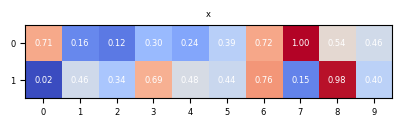

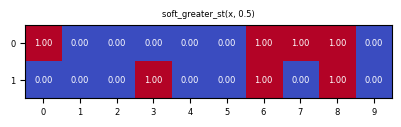

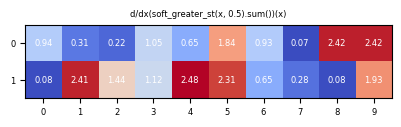

In [10]:
x = torch.rand((2, 10), requires_grad=True)
bool_array = st.greater_st(x, 0.5)
loss = bool_array.sum()
loss.backward()

plot_array(x, title="x")
plot_array(bool_array, title="soft_greater_st(x, 0.5)")
plot_array(x.grad, title="d/dx(soft_greater_st(x, 0.5).sum())(x)")


### Generating soft bools
How does Softtorch make Boolean logic operations differentiable? A real number $x\in \mathbb{R}$ could be mapped to a `Bool` using the Heaviside function
$$
H(x) = \begin{cases}
1, & x > 0 \\
0.5, & x=0\\
0, & x < 0
\end{cases}.
$$
The gradient of the Heaviside function (as implemented in PyTorch) is zero everywhere and hence unsuited for differentiable optimization. Instead of operating directly on Booleans, Softtorch's differentiable logic operators resort to *soft Booleans*. A soft Boolean aka `SoftBool` can be interpreted as the probability of a Boolean being `True`.

We replace the heaviside function with differentiable surrogate such as the sigmoid function $\sigma(x) = \frac{1}{1+e^{-x}}$. While the `sigmoid` is the canonical example for mapping a real number to a `SoftBool`, Softtorch provides additional surrogates.

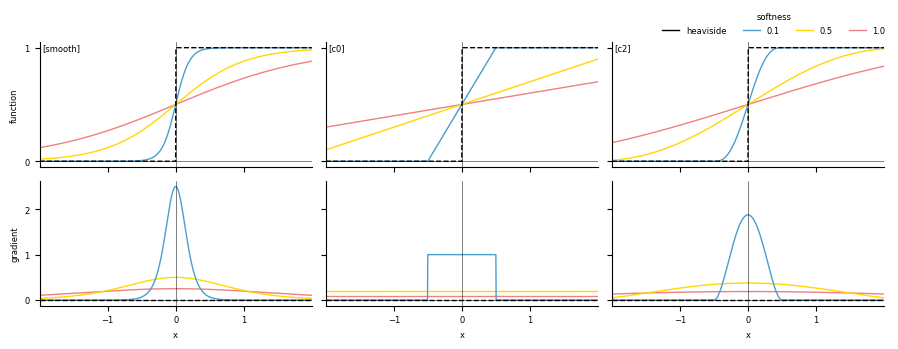

In [11]:
plot(st.heaviside, modes=["smooth", "c0", "c2"])

In the above case, the `c0` and `c2` relaxations have the advantage of altering the original function only in a bounded region, a property that can be desirable in some cases.

Given the concept of a `SoftBool`, a probabilistic surrogate for binary logical operations such as `torch.eq` and `torch.greater` is obtained by simply shifting the sigmoid.

> **Example - Greater operator:** `st.greater(x,y)` corresponds to shifting `st.heaviside` by `y` to the right. The output can be interpreted as the probability $P(x \geq y)\in[0,1]$ with $x\in\mathbb{R}$ and $y\in\mathbb{R}$.

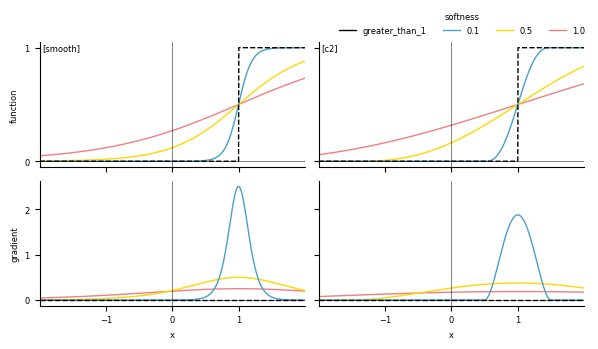

In [12]:
def greater_than_1(x, mode="smooth", softness=0.1):
    return st.greater(x, y=1.0, mode=mode, softness=softness)


plot(greater_than_1, modes=["smooth", "c2"])


### Manipulating soft bools
Softtorch replaces a Boolean with a `SoftBool`, in turn Boolean logic operators are replaced in Softtorch with [fuzzy logic](https://en.wikipedia.org/wiki/Fuzzy_logic) operators that effectively compute the probabilities of Boolean events.

> **Example - Logical NOT:** Given a `SoftBool` $P(B)$ (being the probability that a Boolean event $B$ occurs), the probability of the event not occuring is $P(\bar B) = 1 - P(B)$ as implemented in `st.logical_not`.
```python
def logical_not(x: SoftBool) -> SoftBool:
    return 1 - x
```
Given `st.logical_not`, the probability that `x is not greater equal 0.5` is given by `st.logical_not(st.greater_st(x, 0.5))`. Due to the straight-through trick, the function `st.logical_not(st.greater_st(x, 0.5))` uses exact Boolean logic in the forward pass and the `SoftBool` probability computation in the backward pass.

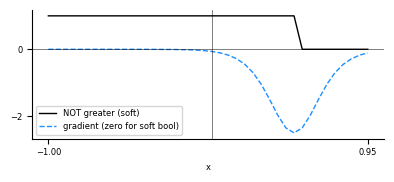

In [13]:
def not_greater_st(x):
    return st.logical_not(st.greater_st(x, y=0.5, mode="smooth", softness=0.1))


x = torch.arange(-1.0, 1.0, 0.05, requires_grad=True)
values = []
grads = []
for x_i in x:
    y = not_greater_st(x_i)
    (g,) = torch.autograd.grad(y, x_i)
    values.append(y.item())
    grads.append(g.item())
values = torch.tensor(values)
grads = torch.tensor(grads)

plot_value_and_grad(
    x.detach(),
    values,
    grads,
    label_func="NOT greater (soft)",
    label_grad="gradient (zero for soft bool)",
)

> **Example - Logical AND:** Given two `SoftBools` $P(A)$ and $P(B)$, the probability that both independent events occur is $P(A \wedge B) = P(A) \cdot P(B)$.
```python
def logical_and(x: SoftBool, y: SoftBool) -> SoftBool:
    return x * y
```

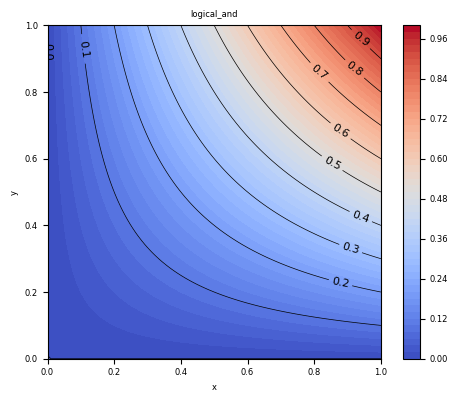

In [14]:
plot_softbool_operation(st.logical_and)


**Example - Logical XOR:** Softtorch computes other soft logic operators such as `st.logical_xor` by combining `st.logical_not` and `st.logical_and`.
```python
def st.logical_xor(x: SoftBool, y: SoftBool) -> SoftBool:
    return logical_or(logical_and(x, logical_not(y)), logical_and(logical_not(x), y))
```

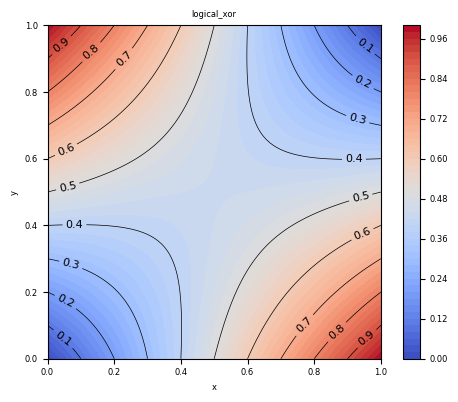

In [15]:
plot_softbool_operation(st.logical_xor)


### Selection with soft bools
Through the use of Fuzzy logic operators, Softtorch provides a toolbox to make many non-differentiable functions of PyTorch differentiable.

> **Example - st.where():** The function `torch.numpy.where(condition, x, y)` selects elements of array `x` if `condition == True` and otherwise selects `y`. Softtorch provides a differentiable surrogate for this function via `st.where(P, x, y)` which effectively computes the expected value $\mathbb{E}[X] = P \cdot x + (1-P) \cdot y$.

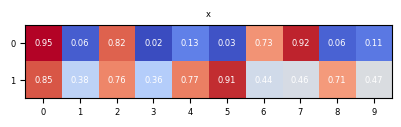

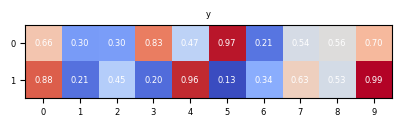

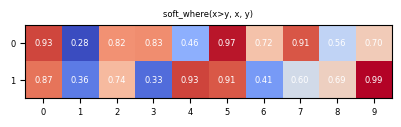

In [16]:
greater = lambda x, y: st.greater(x, y, mode="smooth", softness=0.1)
soft_where = lambda x, y: st.where(greater(x, y), x, y)

x = torch.rand((2, 10))
y = torch.rand((2, 10))
z = soft_where(x, y)


plot_array(x, title="x")
plot_array(y, title="y")
plot_array(soft_where(x, y), title="soft_where(x>y, x, y)")

## 4. Soft indices
Softtorch offers soft surrogates for functions that generate **indices as outputs**, such as `argmax`, `argmin`, `argtopk`, `argmedian`, and `argsort`.
The main mechanism here is to replace hard indices with distributions over indices (`SoftIndex`), allowing for informative gradients.

Similar to how `SoftBool` required going from boolean logic to fuzzy logic, this now requires adjusting functions that do selection via indices. As such, we provide new versions of e.g. `take_along_dim` and `index_select`.
Combining the soft index generation with the selection then allows to define surrogates for the corresponding `max`, `min`, `topk`, `median` and `sort` functions.

### Generating soft indices
In PyTorch, functions like `torch.argmax` return integer indices as outputs, which can take values within {0, ..., len(x)-1}.

In [17]:
x = torch.tensor([1, 2, 3])
print("torch.argmax(x):", torch.argmax(x))


torch.argmax(x): tensor(2)


In comparison, Softtorch computes a `SoftIndex` array. Each entry of a `SoftIndex` array contains the probability that the index is being selected.

In [18]:
x = torch.tensor([1, 2, 3])
print("st.argmax(x):", st.argmax(x))


st.argmax(x): tensor([0.0040, 0.0610, 0.9350])


> **Example - Softmax:** The "softmax" (or more precisely "softargmax") is a commonly used  differentiable surrogate for the `argmax` function (it is also the default softening mode in `st.argmax`). The $\text{softmax}(x) = \frac{\exp(x_i)}{\sum_j\exp(x_j)}$ returns a discrete probability distribution over indices (aka a `SoftIndex`). As shown in the plots below, the softmax is fully differentiable. It is commonly used for multi-class classification and in transformer networks.

When `softness` is low, `st.argmax` concentrates probability on the true maximum index (e.g., `[1.0, 0.0, 0.0]`), recovering the hard maximum. When `softness` is higher, the result smoothly interpolates between values, providing useful gradients for optimization.

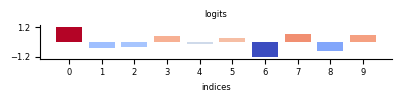

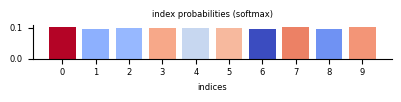

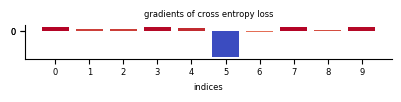

In [19]:
def cross_entropy(x, class_target=5):
    probs = st.argmax(x, softness=10.0)
    target_one_hot = torch.nn.functional.one_hot(
        torch.tensor(class_target, dtype=torch.long), num_classes=x.shape[0]
    ).float()
    return torch.mean(-target_one_hot * torch.log(probs + 1e-9))


x = torch.randn((10,), requires_grad=True)
probs = st.argmax(x, softness=10.0)
loss = cross_entropy(x)
loss.backward()
lossgrads = x.grad

plot_softindices_1D(x, title="logits")
plot_softindices_1D(probs, title="index probabilities (softmax)")
plot_softindices_1D(lossgrads, title="gradients of cross entropy loss")


Note that while in a conventional array of indices, the index information is stored in the integer values, a `SoftIndex` stores the probabilities over possible indices in an extra dimension. By convention, **we always put this additional dimension into the final axis**. Except for this additional final dimension, the shape of the returned soft index matches that of the indices returned by standard PyTorch.
Here are a few examples of this:

In [20]:
x = torch.arange(12).reshape((3, 4))
print("x.shape:", x.shape)
print("torch.argmax(x, dim=1).shape:", torch.argmax(x, dim=1).shape)
print("st.argmax(x, dim=1).shape:", st.argmax(x, dim=1).shape)
print("torch.argmax(x, dim=0).shape:", torch.argmax(x, dim=0).shape)
print("st.argmax(x, dim=0).shape:", st.argmax(x, dim=0).shape)
print(
    "torch.argmax(x, dim=1, keepdim=True).shape:",
    torch.argmax(x, dim=1, keepdim=True).shape,
)
print(
    "st.argmax(x, dim=1, keepdim=True).shape:",
    st.argmax(x, dim=1, keepdim=True).shape,
)
print(
    "torch.argmax(x, dim=0, keepdim=True).shape:",
    torch.argmax(x, dim=0, keepdim=True).shape,
)
print(
    "st.argmax(x, dim=0, keepdim=True).shape:",
    st.argmax(x, dim=0, keepdim=True).shape,
)


x.shape: torch.Size([3, 4])
torch.argmax(x, dim=1).shape: torch.Size([3])
st.argmax(x, dim=1).shape: torch.Size([3, 4])
torch.argmax(x, dim=0).shape: torch.Size([4])
st.argmax(x, dim=0).shape: torch.Size([4, 3])
torch.argmax(x, dim=1, keepdim=True).shape: torch.Size([3, 1])
st.argmax(x, dim=1, keepdim=True).shape: torch.Size([3, 1, 4])
torch.argmax(x, dim=0, keepdim=True).shape: torch.Size([1, 4])
st.argmax(x, dim=0, keepdim=True).shape: torch.Size([1, 4, 3])


We also offer soft versions of `argmedian`, `topk` and `argsort`. The argmedian is returned along with the median value when passing a `dim` argument to the `median` function, similarly for `topk`. This behavior matches that of standard PyTorch, which generally the case for all our functions.

In [21]:
x = torch.rand((4,))
print("x:", x)

print("\ntorch.argmedian:", "Not implemented in standard PyTorch")
print("st.argmedian(x):", st.argmedian(x))

print("\ntorch.argsort(x):", torch.argsort(x))
print("st.argsort(x):", st.argsort(x))

print("\ntorch.topk(x, k=3).indices:", torch.topk(x, k=3).indices)
print("st.topk(x, k=3).indices:", st.topk(x, k=3).indices)

x: tensor([0.8117, 0.0298, 0.3267, 0.8140])

torch.argmedian: Not implemented in standard PyTorch
st.argmedian(x): tensor([0.0144, 0.1072, 0.8647, 0.0138])

torch.argsort(x): tensor([1, 2, 0, 3])
st.argsort(x): tensor([[3.2196e-06, 8.1172e-01, 1.8827e-01, 2.9985e-06],
        [1.4383e-02, 1.0717e-01, 8.6468e-01, 1.3767e-02],
        [4.8879e-01, 1.0764e-04, 3.0211e-02, 4.8089e-01],
        [4.9721e-01, 3.2360e-09, 3.1593e-05, 5.0276e-01]])

torch.topk(x, k=3).indices: tensor([3, 0, 2])
st.topk(x, k=3).indices: tensor([[4.9721e-01, 3.2360e-09, 3.1593e-05, 5.0276e-01],
        [4.8879e-01, 1.0764e-04, 3.0211e-02, 4.8089e-01],
        [1.4383e-02, 1.0717e-01, 8.6468e-01, 1.3767e-02]])


Again, the shape of the returned `SoftIndex` matches that of the normal index array, except for an additional dimension in the last axis that matches the size of the input array along the specified axis. A few examples:

In [22]:
x = torch.rand((3, 4))
print("x.shape:", x.shape)

print(
    "\ntorch.topk(x, k=2, dim=1).indices.shape:",
    torch.topk(x, k=2, dim=1).indices.shape,
)
print("st.topk(x, k=2, dim=1).indices.shape:", st.topk(x, k=2, dim=1).indices.shape)
print(
    "torch.topk(x, k=2, dim=0).indices.shape:", torch.topk(x, k=2, dim=0).indices.shape
)
print("st.topk(x, k=2, dim=0).indices.shape:", st.topk(x, k=2, dim=0).indices.shape)

print("\ntorch.argsort(x, dim=1).shape:", torch.argsort(x, dim=1).shape)
print("st.argsort(x, dim=1).shape:", st.argsort(x, dim=1).shape)
print("torch.argsort(x, dim=0).shape:", torch.argsort(x, dim=0).shape)
print("st.argsort(x, dim=0).shape:", st.argsort(x, dim=0).shape)

print("\ntorch.median(x, dim=1).indices.shape:", torch.median(x, dim=1).indices.shape)
print("st.median(x, dim=1).indices.shape:", st.median(x, dim=1).indices.shape)
print("torch.median(x, dim=0).indices.shape:", torch.median(x, dim=0).indices.shape)
print("st.median(x, dim=0).indices.shape:", st.median(x, dim=0).indices.shape)
print(
    "torch.median(x, dim=1, keepdim=True).indices.shape:",
    torch.median(x, dim=1, keepdim=True).indices.shape,
)
print(
    "st.median(x, dim=1, keepdim=True).indices.shape:",
    st.median(x, dim=1, keepdim=True).indices.shape,
)
print(
    "torch.median(x, dim=0, keepdim=True).indices.shape:",
    torch.median(x, dim=0, keepdim=True).indices.shape,
)
print(
    "st.median(x, dim=0, keepdim=True).indices.shape:",
    st.median(x, dim=0, keepdim=True).indices.shape,
)

x.shape: torch.Size([3, 4])

torch.topk(x, k=2, dim=1).indices.shape: torch.Size([3, 2])
st.topk(x, k=2, dim=1).indices.shape: torch.Size([3, 2, 4])
torch.topk(x, k=2, dim=0).indices.shape: torch.Size([2, 4])
st.topk(x, k=2, dim=0).indices.shape: torch.Size([2, 4, 3])

torch.argsort(x, dim=1).shape: torch.Size([3, 4])
st.argsort(x, dim=1).shape: torch.Size([3, 4, 4])
torch.argsort(x, dim=0).shape: torch.Size([3, 4])
st.argsort(x, dim=0).shape: torch.Size([3, 4, 3])

torch.median(x, dim=1).indices.shape: torch.Size([3])
st.median(x, dim=1).indices.shape: torch.Size([3, 4])
torch.median(x, dim=0).indices.shape: torch.Size([4])
st.median(x, dim=0).indices.shape: torch.Size([4, 3])
torch.median(x, dim=1, keepdim=True).indices.shape: torch.Size([3, 1])
st.median(x, dim=1, keepdim=True).indices.shape: torch.Size([3, 1, 4])
torch.median(x, dim=0, keepdim=True).indices.shape: torch.Size([1, 4])
st.median(x, dim=0, keepdim=True).indices.shape: torch.Size([1, 4, 3])


Note: All of the functions in this section come with the five modes: `hard`, `smooth`, `c0`, `c1`, and `c2`.
`hard` mode produces one-hot soft indices and is mainly used in straight-through estimation. `smooth` (entropic) is the recommended soft default and reduces all operations to either a softmax or an entropy-regularized optimal transport problem.
`c0` (L2) reduces operations to L2 projection onto the unit simplex or the Birkhoff polytope, which can be used to produce sparse outputs. `c1` (p=3/2 p-norm) provides C1 differentiable projections, and `c2` (p=4/3 p-norm) provides C2 twice-differentiable projections. See the API documentation for details.

### Selection with SoftIndices

Given a `SoftIndex`, Softtorch provides (differentiable) helper functions for selecting array elements, mirroring the non-differentiable indexing in standard PyTorch. Put simply, entries of an array are selected by computing the expected value:

$$\mathrm{E}(arr, p) = \sum_{i} arr[i] \cdot p[i] = arr^{\top} \cdot p$$

where $p$ is the `SoftIndex`.


> **Example `st.take_along_dim`:** The function `st.take_along_dim` is central to this selection mechanism. It generalizes `torch.take_along_dim` to work with probability distributions (SoftIndices) instead of just integer indices.

The standard `torch.take_along_dim(arr, indices, dim)` selects elements from `arr` using integer indices. Conceptually, it works by:
1. Slicing along the specified dim to get 1D arrays
2. Using the corresponding indices to select elements
3. Assembling the results into the output array

One of its main uses is to accept the index output of e.g. `torch.argmax` and [select the maximum values at the indexed locations](https://docs.pytorch.org/docs/stable/generated/torch.take_along_dim.html).
While `torch.take_along_dim` uses integer indices `out_1d[j] = arr_1d[indices_1d[j]]`, `st.take_along_dim` accepts a `SoftIndex` to compute the corresponding the weighted sum: `out_1d[j] = sum_i(arr_1d[i] * soft_indices_2d[j, i])`.

In [23]:
x = torch.rand((2, 3))
print("x:\n", x)

indices = torch.argmin(x, dim=1, keepdim=True)
print("min_torch:\n", torch.take_along_dim(x, indices, dim=1))

indices_one_hot = st.argmin(x, dim=1, mode="hard", keepdim=True)
print("min_st_hard:\n", st.take_along_dim(x, indices_one_hot, dim=1))

indices_soft = st.argmin(x, dim=1, keepdim=True)
print("min_st_soft:\n", st.take_along_dim(x, indices_soft, dim=1))


x:
 tensor([[0.0064, 0.0695, 0.6306],
        [0.0861, 0.9201, 0.1303]])
min_torch:
 tensor([[0.0064],
        [0.0861]])
min_st_hard:
 tensor([[0.0064],
        [0.0861]])
min_st_soft:
 tensor([[0.0329],
        [0.1089]])


As a convenience, this combination of `st.take_along_dim` with `SoftIndex`-generating functions is already implemented in Softtorch's `max`, `median`, `topk` and `sort` functions.

In [24]:
x = torch.rand((4,))
print("x:", x)

print("\ntorch.max(x):", torch.max(x))
print("st.max(x, mode='hard'):", st.max(x, mode="hard"))
print("st.max(x):", st.max(x))

print("\ntorch.median(x):", torch.median(x))
print("st.median(x, mode='hard'):", st.median(x, mode="hard"))
print("st.median(x):", st.median(x))

print("\ntorch.topk(x, k=2).values:", torch.topk(x, k=2).values)
print("st.topk(x, k=2, mode='hard').values:", st.topk(x, k=2, mode="hard").values)
print("st.topk(x, k=2).values:", st.topk(x, k=2).values)

print("\ntorch.sort(x).values:", torch.sort(x).values)
print("st.sort(x, mode='hard').values:", st.sort(x, mode="hard").values)
print("st.sort(x).values:", st.sort(x).values)

x: tensor([0.8815, 0.8314, 0.1828, 0.2114])

torch.max(x): tensor(0.8815)
st.max(x, mode='hard'): tensor(0.8815)
st.max(x): tensor(0.8537)

torch.median(x): tensor(0.2114)
st.median(x, mode='hard'): tensor(0.2114)
st.median(x): tensor(0.2053)

torch.topk(x, k=2).values: tensor([0.8815, 0.8314])
st.topk(x, k=2, mode='hard').values: tensor([0.8815, 0.8314])
st.topk(x, k=2).values: tensor([0.8597, 0.8455])

torch.sort(x).values: tensor([0.1828, 0.2114, 0.8314, 0.8815])
st.sort(x, mode='hard').values: tensor([0.1828, 0.2114, 0.8314, 0.8815])
st.sort(x).values: tensor([0.1960, 0.2053, 0.8455, 0.8597])


Finally, we also offer a soft `rank` operation. While it does not return a `SoftIndex` (because its output is the same shape as the input), it relies on similar computations under the hood as e.g. `sort`, and also offers the same modes.

In [25]:
x = torch.rand((5,))
print("x:\n", x)
# This computes the ranking operation
print("torch.argsort(torch.argsort(x)):\n", torch.argsort(torch.argsort(x)))
print(
    "st.rank(x, descending=False, mode='hard'):\n",
    st.rank(x, descending=False, mode="hard"),
)
print("st.rank(x, descending=False):\n", st.rank(x, descending=False))

x:
 tensor([0.8887, 0.3100, 0.7068, 0.7704, 0.3770])
torch.argsort(torch.argsort(x)):
 tensor([4, 0, 2, 3, 1])
st.rank(x, descending=False, mode='hard'):
 tensor([5., 1., 3., 4., 2.])
st.rank(x, descending=False):
 

tensor([4.7733, 1.3568, 3.3384, 3.9469, 1.6290])
